In [1]:
import sys
import os
sys.path.append("../../src/")
#Imports
import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter

In [2]:
#Params
L = 1000
J = 1
g = 1
k = kb.k_vals(L)
U = kb.U(k,g)
x= np.arange(1,50,dtype=int)

/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


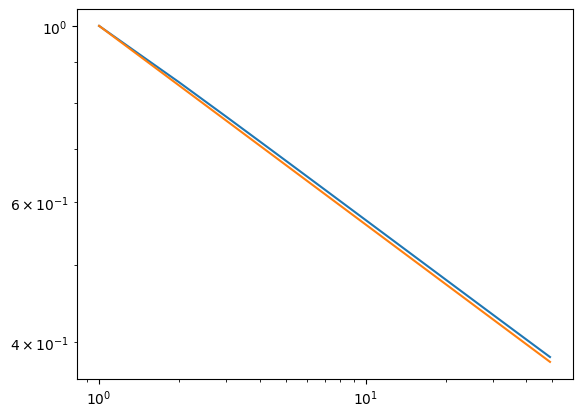

In [3]:
plt.loglog(x,[kb.sigma_general([0,xi],U,k)/kb.sigma_general([0,1],U,k) for xi in x])
plt.loglog(x,x**(-1/4))

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


[0, 1]
[(np.int64(0),), (np.int64(0), np.int64(1))]
[0, 2]
[(np.int64(0),), (np.int64(0), np.int64(2))]
[0, 3]
[(np.int64(0),), (np.int64(0), np.int64(3))]
[0, 4]
[(np.int64(0),), (np.int64(0), np.int64(4))]
[0, 5]
[(np.int64(0),), (np.int64(0), np.int64(5))]
[0, 6]
[(np.int64(0),), (np.int64(0), np.int64(6))]
[0, 7]
[(np.int64(0),), (np.int64(0), np.int64(7))]
[0, 8]
[(np.int64(0),), (np.int64(0), np.int64(8))]
[0, 9]
[(np.int64(0),), (np.int64(0), np.int64(9))]
[0, 10]
[(np.int64(0),), (np.int64(0), np.int64(10))]
[0, 11]
[(np.int64(0),), (np.int64(0), np.int64(11))]
[0, 12]
[(np.int64(0),), (np.int64(0), np.int64(12))]
[0, 13]
[(np.int64(0),), (np.int64(0), np.int64(13))]
[0, 14]
[(np.int64(0),), (np.int64(0), np.int64(14))]
[0, 15]
[(np.int64(0),), (np.int64(0), np.int64(15))]
[0, 16]
[(np.int64(0),), (np.int64(0), np.int64(16))]
[0, 17]
[(np.int64(0),), (np.int64(0), np.int64(17))]
[0, 18]
[(np.int64(0),), (np.int64(0), np.int64(18))]
[0, 19]
[(np.int64(0),), (np.int64(0), np.int6

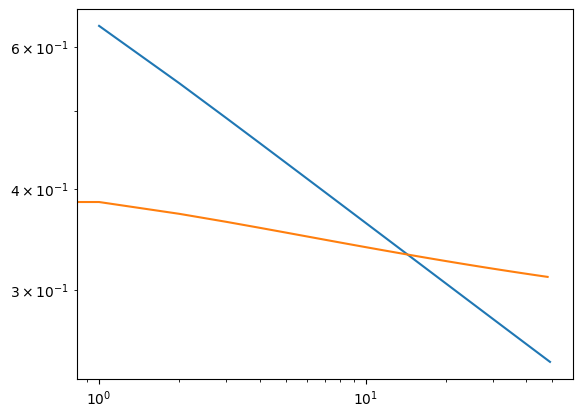

In [46]:
plt.loglog(x,[kb.sigma_general([0,xi],U,k) for xi in x])

plt.loglog([P_n_correlations(1,l,U,k,even=True) for l in x])

In [86]:
def P_n_correlations(n,l,U,k, even = True):
    #Term 1 
    indices = [i for i in range(0,n)]
    #Term 2 
    indices +=[i for i in range(n+l-1,2*n+l-1)]

    terms = kb.all_combinations(indices)
     ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = kb.Counter(x_c)
    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))
    #
    dat = []
    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(kb.sigma_general(indices,U,k))*degen)
        else:
            dat.append(kb.sigma_general(indices,U,k)*degen)
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**(2*n)#,terms


In [98]:
dat = []

for n in range(2,8,2):
    print(n)
    P = [kb.P_n_correlations(n,xi,U,k,True)-kb.P_n(n,U,k)**2 for xi in x]
    dat.append(P)




2


/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


4
6
